In [3]:
import pandas as pd
import numpy as np
import seaborn as sns

df = pd.read_csv("Data/allyears.csv", index_col="id")
df["date"] = pd.to_datetime(df["date"])
df["client"] = df["client"].str.lower()
df["client"] = df["client"].str.strip()
df["client"] = df["client"].str.title()


cdf = (
    df.groupby("client")["date"]
    .agg(count="count", first_time="min", last_time="max")
    .reset_index()
)

cdf["months"] = (
    cdf["last_time"].dt.to_period("M") - cdf["first_time"].dt.to_period("M")
).apply(lambda x: x.n)

print(cdf)


                   client  count first_time  last_time  months
0                 A Chris      1 2025-09-09 2025-09-09       0
1           Aaron Ornelas      1 2024-03-01 2024-03-01       0
2           Abby Trujillo      1 2025-04-16 2025-04-16       0
3     Abdelaziz Aboelseud      4 2025-02-14 2025-05-15       3
4          Abigail Barney      6 2025-01-11 2025-11-06      10
...                   ...    ...        ...        ...     ...
2483         Zeke Tripodi     15 2024-04-24 2025-11-07      19
2484         Zina Salcedo      1 2025-12-04 2025-12-04       0
2485        Zoie Langford     51 2024-01-03 2025-12-16      23
2486    Zoie Langford (R)      2 2025-09-26 2025-10-28       1
2487      Zullany Padilla      5 2024-10-22 2025-01-16       3

[2488 rows x 5 columns]


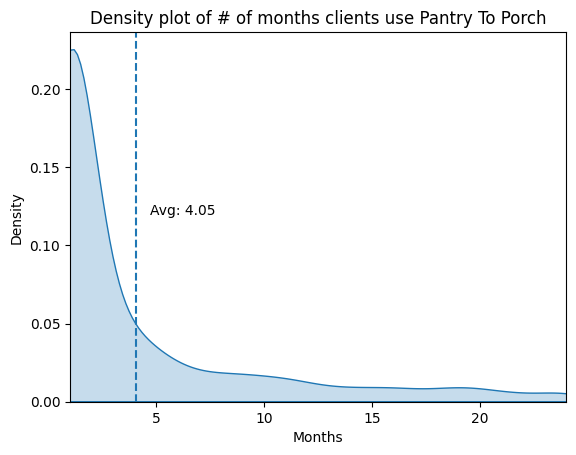

In [59]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
sns.kdeplot(cdf["months"], ax=ax, fill=True)
ax.set_xlim(1,24)
ax.set_title("Density plot of # of months clients use Pantry To Porch")
ax.set_xlabel("Months")

ax.axvline(x=cdf["months"].mean(), linestyle="--")

mean = cdf["months"].mean()
fig.text(x=0.25, y=0.5, s=f"Avg: {round(mean, 2)}")

fig.savefig("Visuals/jon-months-density.png", dpi=500)

In [ ]:

def bucket(num):
    if num == 1:
        return "1 Time"
    elif num == 2:
        return "2 Times"
    elif num >= 3 and num <= 5:
        return "3-5 Times"
    elif num >= 6 and num <= 10:
        return "6-10 Times"
    elif num >= 11 and num <= 20:
        return "11-20 Times"
    elif num >= 21 and num <= 40:
        return "21-40 Times"
    elif num > 40:
        return ">40 Times"
        

cdf["bucket"] = cdf["count"].apply(bucket)


cdf.to_csv("Data/jon-client.csv")

sum(cdf["bucket"] == "31-50 Times")



np.int64(1)